In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time
import random

In [3]:
# prepare dataset
batch_size = 64
transform = transforms.Compose(
    [
    transforms.ToTensor(),    # 将 PIL 图像转换为 Tensor
    transforms.Normalize((0.1307,), (0.3081,))
    ]    # 标准化，均值为0.1307， 标准差为0.3081, 对转换成Tensor的图像进行标准化处理，以避免数据分布不均导致模型训练困难。
)

train_dataset = datasets.MNIST(root='./dataset/mnist/', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./dataset/mnist/', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"size of train_loader: {train_loader.dataset.data.size()}")    # 打印训练数据集的大小
print(f"shape of train_loader: {train_loader.dataset.data.shape}")    # 打印训练数据集的形状
print(f"size of test_loader: {test_loader.dataset.data.size()}")
print(f"shape of test_loader: {test_loader.dataset.data.shape}")
# size of train_loader: torch.Size([60000, 28, 28]), 60000是样本数量, 28*28是图像尺寸
# train_loader 是一个DataLoader对象，用于将训练数据集转换为可迭代的批次，每个批次包含batch_size个样本，每个样本包含一个28*28的图像和对应的标签。
# Minst数据集由28*28的图像和对应的标签组成，图像的像素值在0-255之间，标签在0-9之间。

size of train_loader: torch.Size([60000, 28, 28])
shape of train_loader: torch.Size([60000, 28, 28])
size of test_loader: torch.Size([10000, 28, 28])
shape of test_loader: torch.Size([10000, 28, 28])


In [4]:
# design model using class
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()    # 继承父类
        self.l1 = torch.nn.Linear(784, 512)    # 输入层，输入特征为784，输出特征为512
        self.l2 = torch.nn.Linear(512, 256)    # 隐藏层，输入特征为512，输出特征为256
        self.l3 = torch.nn.Linear(256, 128)
        self.l4 = torch.nn.Linear(128, 64)
        self.l5 = torch.nn.Linear(64, 10)    # 输出层，输入维度为64，输出维度为10

    def forward(self, x):    # 定义前向传播，x 为输入数据
        x = x.view(-1, 784)    # 原本输入形状为(batch_size, 1, 28, 28), 1是通道数，28*28为像素数量。这里展平为(batch_size, 784)
        x = F.relu(self.l1(x))    # 经过第一层线性变换后，使用ReLU激活函数
        x = F.relu(self.l2(x))
        x = F.relu(self.l3(x))
        x = F.relu(self.l4(x))
        x = self.l5(x)    # 最后一层不用激活函数，因为激活函数已经包含在了CrossEntropyLoss中
        return x

model = Net()    # 模型实例化
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
# Net 输入数据为28*28的图像，展平为784维的向量，然后输入到Net中，输出为10个类别的概率
# 输出为10个类别的概率，概率最大的类别即为预测的结果

Net(
  (l1): Linear(in_features=784, out_features=512, bias=True)
  (l2): Linear(in_features=512, out_features=256, bias=True)
  (l3): Linear(in_features=256, out_features=128, bias=True)
  (l4): Linear(in_features=128, out_features=64, bias=True)
  (l5): Linear(in_features=64, out_features=10, bias=True)
)

In [9]:
# construct loss and optimizer
criterion = torch.nn.CrossEntropyLoss()    # 使用交叉熵函数作为损失函数
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)    # 使用SGD优化器

In [10]:
# training cycle forward, backward, update
def train(epoch):
    model.train()
    running_loss = 0.0    # 用于每200个batch打印
    epoch_loss = 0.0      # 用于记录整个epoch平均loss
    num_batches = 0
    train_correct = 0
    train_total = 0

    for batch_idx, data in enumerate(train_loader, 0):
        '''
        batch_idx 是当前批次索引, data 是当前批次的数据和标签
        (train_loader, 0) 表示从train_loader中获取数据, 从0开始计数
        '''
        inputs, labels = data    # 获取当前循环的索引批次对应的输入数据和标签
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()    # 每一次循环开始时，先进行梯度清零

        outputs = model(inputs)    # 将输入数据传入模型Net，得到输出
        loss = criterion(outputs, labels)    # 损失函数计算
        loss.backward()    # 计算完损失函数后，进行反向传播, 计算梯度
        optimizer.step()    # 计算完梯度后，进行参数更新

        running_loss += loss.item()    # 损失值累加到running_loss中
        epoch_loss += loss.item()
        num_batches += 1

        _, predicted = torch.max(outputs.data, dim=1)
        train_total += labels.size(0)    # 获取标签的数量作为训练的总数量
        train_correct += (predicted == labels).sum().item()

        # 每200个批次打印一次损失，查看依次训练的损失
        if batch_idx % 200 == 199:
            print(f"[epoch {epoch + 1}, batch {batch_idx + 1}] loss: {running_loss / 200}")
            running_loss = 0.0

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)
    train_accs.append(100 * train_correct / train_total)

In [11]:
# test
def test():
    '''
    return: 预测结果
    '''
    model.eval()
    correct = 0.0
    total = 0.0
    test_loss = 0.0
    num_batches = 0    # 记录测试集的批次数量

    with torch.no_grad():    # 推理阶段不需要计算梯度
        for data in test_loader:    # 获取测试集中的数据，数据由28*28的灰度图像和对应的标签组成
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            test_loss += loss.item()
            num_batches += 1

            # 获取输出中最大概率的索引
            # dim = 1 沿着列的方向取最大值，即按行取最大值，即从第一行开始，取每一行的所有列中列的最大值
            # 返回最大值的索引和最大值
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)    # 获取标签的数量
            correct += (predicted == labels).sum().item()    # 计算预测正确的数量

    avg_test_loss = test_loss / num_batches
    avg_test_acc = 100 * correct / total
    test_losses.append(avg_test_loss)
    test_accs.append(avg_test_acc)
    print(f"Accuracy of the network on the 10000 test images: {avg_test_acc}%")

[epoch 1, batch 200] loss: 0.02497057286906056
[epoch 1, batch 400] loss: 0.025130241836886853
[epoch 1, batch 600] loss: 0.02475096375157591
[epoch 1, batch 800] loss: 0.025997355941217392
Accuracy of the network on the 10000 test images: 97.24%
[epoch 2, batch 200] loss: 0.017240422022005077
[epoch 2, batch 400] loss: 0.020737786488025448
[epoch 2, batch 600] loss: 0.019168481409869854
[epoch 2, batch 800] loss: 0.024640483601833695
Accuracy of the network on the 10000 test images: 97.75%
[epoch 3, batch 200] loss: 0.014524292284040712
[epoch 3, batch 400] loss: 0.01575991653924575
[epoch 3, batch 600] loss: 0.013601492183806841
[epoch 3, batch 800] loss: 0.018814864849264267
Accuracy of the network on the 10000 test images: 97.8%
[epoch 4, batch 200] loss: 0.010678733143722639
[epoch 4, batch 400] loss: 0.013618706997076515
[epoch 4, batch 600] loss: 0.011378533350070939
[epoch 4, batch 800] loss: 0.012717118768341607
Accuracy of the network on the 10000 test images: 97.73%
[epoch 5

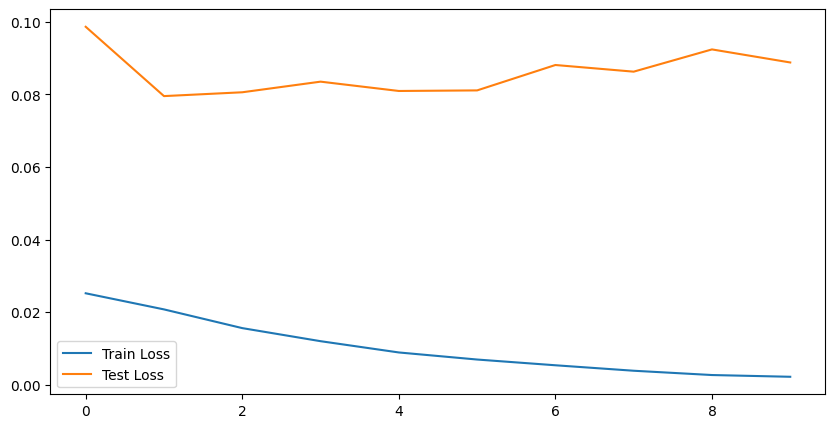

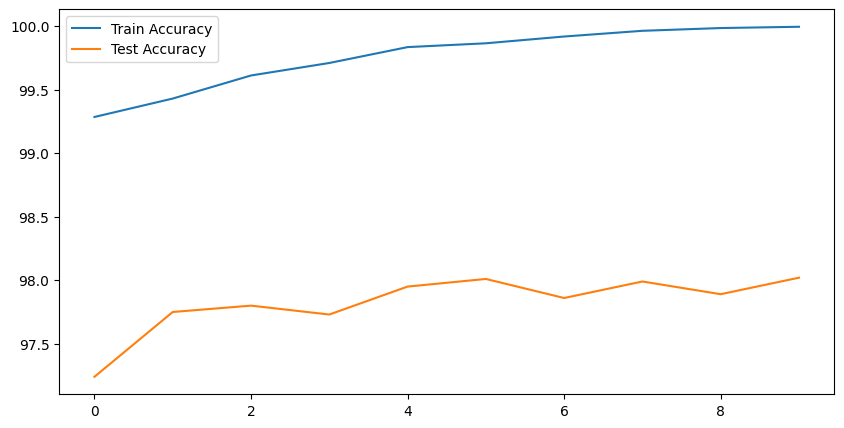

In [12]:
# 开始训练和测试，以及loss曲线和准确率曲线的可视化
if __name__ == "__main__":
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(10):
        train(epoch)
        test()

    # 可视化loss曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.legend()
    plt.show()

    # 可视化准确率曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.legend()
    plt.show()